<a href="https://www.kaggle.com/datasets/khesham23/best-model-albert">you can use the output of trained model from here </a>

**Dataset:**
emotion from HuggingFace

**Objective:**
Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise.

### Import used libraries

In [1]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns

import contractions
import re

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay


from tqdm import tqdm
import logging



### Load Dataset

In [3]:
df = load_dataset("dair-ai/emotion", "split")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
train = df['train'].to_pandas()
test = df['test'].to_pandas()
val = df['validation'].to_pandas()

In [5]:
train.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3


In [6]:
label_to_index = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}
index_to_label = {v: k for k, v in label_to_index.items()}

In [7]:
print(f"Number of training samples: {len(train)}")
print(f"Number of testing samples: {len(test)}")
print(f"Number of validation samples: {len(val)}")

Number of training samples: 16000
Number of testing samples: 2000
Number of validation samples: 2000


### EDA on training data

- check NaNs

In [8]:
train.isna().sum()

text     0
label    0
dtype: int64

- check duplicated

In [9]:
train.duplicated().sum()

np.int64(1)

In [10]:
train[train.duplicated(keep=False)]

,text,label
4975,i feel more adventurous willing to take risks img src http cdn,1
13846,i feel more adventurous willing to take risks img src http cdn,1


- show a representative sample of data texts to find out required preprocessing steps

In [11]:
print(train.iloc[1]['text'])

i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


- show max row length in train

In [12]:
max_length = train['text'].str.split().apply(len).max()
print(f"Maximum text length: {max_length}")

Maximum text length: 66


- check dataset balancing

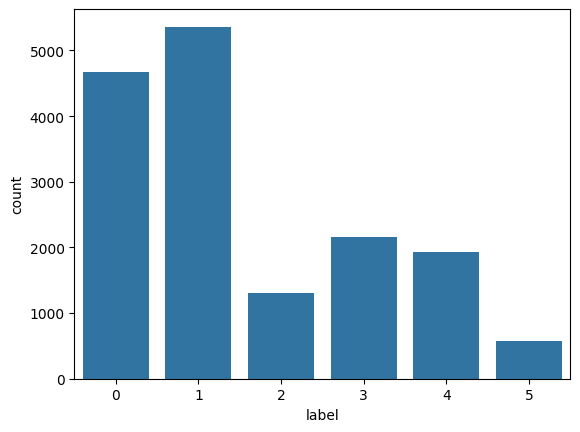

In [13]:
sns.countplot(x="label", data=train)
plt.show()

**the data is imbalanced**

- Cleaning and Preprocessing are:
    - 1 strip spaces
    - 2 normalize weird spaces
    - 3 fix contractions
    - 4 remove urls
    - 5 remove mentions

### Cleaning and Preprocessing

In [14]:
class TextPreprocessor:
    def preprocess_text(self, text):

        text = re.sub(r"\s+", " ", text).strip()

        text =re.sub(r"http\S+|www\S+|https\S+", '', text)

        text = re.sub(r"@\w+", "", text)
        
        text = contractions.fix(text)

        return text
    def transform(self, X):
        return self.preprocess_text(X)

In [15]:
a = TextPreprocessor()
print(a.transform(train.iloc[0]["text"]))

i did not feel humiliated


In [16]:
print(train.iloc[0]["text"])

i didnt feel humiliated


# Tokenizer

In [17]:
model_name = "albert/albert-base-v2"

In [18]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Modelling

In [19]:
class EmotionDataset(Dataset):
    def __init__(self, data , preprocessor, tokenizer, max_length=128):
        self.data = data
        self.preprocessor = preprocessor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]
        text = row['text']
        label = row['label']

        text = self.preprocessor.transform(text)

        inputs = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length = self.max_length,
            return_tensors='pt'
            )
        inputs = {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0)
        }

        return inputs, torch.tensor(label, dtype=torch.long)

In [20]:
train_dataset = EmotionDataset(train, TextPreprocessor(), tokenizer, max_length=128)
val_dataset = EmotionDataset(val, TextPreprocessor(), tokenizer, max_length=128)
test_dataset = EmotionDataset(test, TextPreprocessor(), tokenizer, max_length=128)

In [21]:
train_dataset[0]

({'input_ids': tensor([    2,    31,   144,    52,   583, 26951,     3,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,    

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [23]:
for batch in train_loader:
    inputs, labels = batch
    print(inputs['input_ids'].shape)
    print(labels.shape)
    break

torch.Size([32, 128])
torch.Size([32])


In [24]:
class EmotionModel(nn.Module):
    def __init__(self, model_name, output_dim=6, dropout=0.3):
        super(EmotionModel, self).__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(self.bert.config.hidden_size, output_dim)
 
    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  
        cls_output = self.dropout(cls_output)
        return self.fc(cls_output)  

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [26]:
class_counts = train['label'].value_counts().sort_index()

weights = 1.0 / class_counts
weights = weights / weights.sum()

class_weights = torch.tensor(weights.values, dtype=torch.float32)
class_weights

tensor([0.0550, 0.0479, 0.1969, 0.1189, 0.1325, 0.4488])

In [27]:
model = EmotionModel(model_name = model_name).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert/albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
model

EmotionModel(
  (bert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_fea

In [29]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
class Trainer:
    def __init__(
        self,
        model,
        criterion,
        optimizer,
        device,
        
    ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
        self.results = self._initialize_results_dict()
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0
        self.start_epoch = 1
        
        


    def _initialize_results_dict(self):
        
        return {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': [],
        }
    def _calculate_accuracy(self, outputs, labels):
        _, predicted = torch.max(outputs, 1)
        return torch.mean((predicted == labels).float()) * 100

    def _train_epoch(self, train_loader) :

        self.model.train()
        epoch_loss = 0.0
        epoch_accuracy = 0.0
        progress_bar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc="Training",
            unit='batch'
        )
        for i, (inputs, labels) in progress_bar:
            input_ids = inputs['input_ids'].to(self.device)
            attention_mask = inputs['attention_mask'].to(self.device)
            labels = labels.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(
                input_ids = input_ids,
                attention_mask = attention_mask)
            
            loss = self.criterion(outputs, labels)

            epoch_loss += loss.item()
            loss.backward()
            self.optimizer.step()
            batch_accuracy = self._calculate_accuracy(outputs, labels)
            epoch_accuracy += batch_accuracy
            progress_bar.set_postfix({
                'loss': f"{loss.item()}",
                'accuracy': f"{batch_accuracy}"
            })
        num_batches = len(train_loader)
        metrics = {
            'loss': epoch_loss / num_batches,
            'accuracy': epoch_accuracy / num_batches
        }
        return metrics


    def _validate_epoch(self, val_loader) :

        self.model.eval()
        epoch_loss = 0.0
        epoch_accuracy = 0.0
        with torch.no_grad():
            progress_bar = tqdm(
                enumerate(val_loader),
                total=len(val_loader),
                desc="Validation",
                unit='batch'
            )
            for i, (inputs, labels) in progress_bar:
                input_ids = inputs['input_ids'].to(self.device)
                attention_mask = inputs['attention_mask'].to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(
                    input_ids = input_ids,
                    attention_mask = attention_mask
                )
                loss = self.criterion(outputs, labels)
                epoch_loss += loss.item()
                batch_accuracy = self._calculate_accuracy(outputs, labels)
                epoch_accuracy += batch_accuracy
                progress_bar.set_postfix({
                    'loss': f"{loss.item()}",
                    'accuracy': f"{batch_accuracy}"
                })
        num_batches = len(val_loader)
        return {
            'loss': epoch_loss / num_batches,
            'accuracy': epoch_accuracy / num_batches
        }

    def _save_checkpoint(
        self,
        epoch,
        val_loss,
        val_accuracy,
        model_name,
    ):

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
            'results': self.results
        }
        
        checkpoint_path = f'best_model_{model_name}.pth'
        torch.save(checkpoint, checkpoint_path)
        print(f"Saved checkpoint to {checkpoint_path}")


    def train(
        self,
        train_loader,
        val_loader,
        num_epochs = 20,
        patience = 3,
        model_name = "model",
    ):

        print(f"Starting training on {self.device}")
        
        for epoch in range(self.start_epoch, num_epochs + 1):
            print(f"\nepoch {epoch}/{num_epochs}")
            
            train_metrics = self._train_epoch(train_loader)
            val_metrics = self._validate_epoch(val_loader)
            
            self._update_results(train_metrics, val_metrics)
            
            self._print_epoch_summary(epoch, num_epochs, train_metrics, val_metrics)
            
            improved = self._check_improvement(epoch, val_metrics, model_name)

            if not improved:
                self.early_stop_counter += 1
                print(f"no improvement in validation loss for {self.early_stop_counter} epochs")
                
                if self.early_stop_counter >= patience:
                    print(f"early stopping triggered after {epoch} epochs")
                    break
            else:
                self.early_stop_counter = 0
        
        return self.results
        


    def _update_results(
        self,
        train_metrics,
        val_metrics
    ):

        self.results['train_losses'].append(train_metrics['loss'])
        self.results['val_losses'].append(val_metrics['loss'])
        self.results['train_accuracies'].append(train_metrics['accuracy'])
        self.results['val_accuracies'].append(val_metrics['accuracy'])

    def _check_improvement(
        self,
        epoch,
        val_metrics,
        model_name
    ):
        if val_metrics['loss'] < self.best_val_loss:
            self.best_val_loss = val_metrics['loss']
            self._save_checkpoint(epoch, val_metrics['loss'], val_metrics['accuracy'], model_name)
            print(f"model improved! best validation loss: {self.best_val_loss:.4f}")
            return True 
        return False

    def _print_epoch_summary(
        self,
        epoch,
        num_epochs,
        train_metrics,
        val_metrics
    ):

        print("\n" + "="*50)
        print(f"epoch {epoch}/{num_epochs}")        
        print("\nMetrics:")
        print(f"train_loss: {train_metrics['loss']:.4f} and train_accuracy: {train_metrics['accuracy']:.2f}%")
        print(f"val_loss: {val_metrics['loss']:.4f} and val_accuracy: {val_metrics['accuracy']:.2f}%")
        print("="*50)





In [30]:
emotion_trainer = Trainer(model, criterion, optimizer, device)

In [31]:
results = emotion_trainer.train(train_loader, val_loader, num_epochs=50, patience=3, model_name="albert")

Starting training on cuda

epoch 1/50


Validation: 100%|██████████| 63/63 [00:15<00:00,  4.02batch/s, loss=0.24802972376346588, accuracy=87.5]



epoch 1/50

Metrics:
train_loss: 0.7645 and train_accuracy: 70.55%
val_loss: 0.2544 and val_accuracy: 89.63%
Saved checkpoint to best_model_albert.pth
model improved! best validation loss: 0.2544

epoch 2/50


Validation: 100%|██████████| 63/63 [00:15<00:00,  4.03batch/s, loss=0.21292833983898163, accuracy=87.5]



epoch 2/50

Metrics:
train_loss: 0.2093 and train_accuracy: 91.84%
val_loss: 0.2005 and val_accuracy: 92.31%
Saved checkpoint to best_model_albert.pth
model improved! best validation loss: 0.2005

epoch 3/50


...


epoch 11/50

Metrics:
train_loss: 0.0949 and train_accuracy: 95.56%
val_loss: 0.1811 and val_accuracy: 93.20%
no improvement in validation loss for 1 epochs

epoch 12/50


Validation: 100%|██████████| 63/63 [00:15<00:00,  4.05batch/s, loss=0.3608037531375885, accuracy=81.25]



epoch 12/50

Metrics:
train_loss: 0.0850 and train_accuracy: 96.08%
val_loss: 0.1722 and val_accuracy: 93.15%
no improvement in validation loss for 2 epochs

epoch 13/50


Validation: 100%|██████████| 63/63 [00:15<00:00,  4.04batch/s, loss=0.2655121386051178, accuracy=81.25]


epoch 13/50

Metrics:
train_loss: 0.0874 and train_accuracy: 96.26%
val_loss: 0.2663 and val_accuracy: 89.78%
no improvement in validation loss for 3 epochs
early stopping triggered after 13 epochs


In [32]:
def plot_training_metrics(model_performance):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=model_performance, x=model_performance.index, y="train_losses", label='Train', ax=ax)
    sns.lineplot(data=model_performance,x=model_performance.index,y="val_losses",label='Validation',ax=ax)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.show()

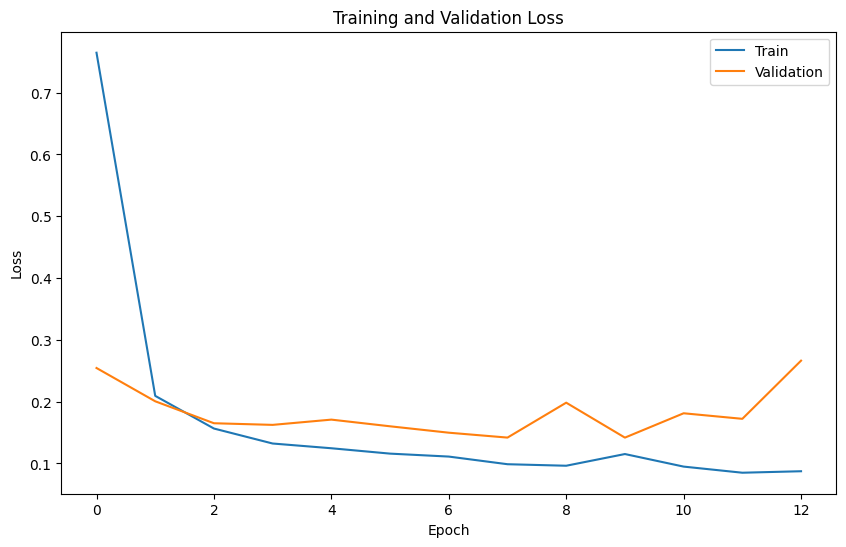

In [33]:
plot_training_metrics(pd.DataFrame({
    "train_losses": results["train_losses"],
    "val_losses": results["val_losses"]
    }))

best model at epoch 2

#### Evaluation

**Evaluation metric:**
Precision

In [34]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    return torch.mean((predicted == labels).float()) * 100


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    total_acc = 0

    predictions = []
    targets = []

    with torch.no_grad():
        progress_bar = tqdm(
            enumerate(dataloader),
            total=len(dataloader),
            desc="Evaluating",
            unit='batch'
        )
        for i, (inputs, target) in progress_bar:
            
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            target = target.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
                )

            loss = criterion(outputs, target)
            total_loss += loss.item()

            batch_accuracy = calculate_accuracy(outputs, target)
            total_acc += batch_accuracy

            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy().tolist())
            targets.extend(target.cpu().numpy().tolist())

    num_batches = len(dataloader)

    return (
        float(total_loss / num_batches),
        float(total_acc / num_batches),
        predictions,
        targets
    )

In [35]:
checkpoint_path = f"best_model_albert.pth.pth"

In [36]:
checkpoint = torch.load(checkpoint_path, map_location = device, weights_only=False)

FileNotFoundError: [Errno 2] No such file or directory: 'best_model_albert.pth.pth'

In [ ]:
best_model = EmotionModel(model_name = model_name).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

In [ ]:
val_loss, val_acc, val_preds, val_targets= evaluate(best_model, val_loader, criterion, device)

In [ ]:
print(f"val loss: {val_loss}, val accuracy: {val_acc}%")

In [ ]:
def compute_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=np.arange(len(index_to_label))
    )
    return cm
cm = compute_confusion_matrix(val_targets,val_preds)

In [ ]:
print(classification_report(val_targets, val_preds, target_names=list(map(str, label_to_index.keys()))))

In [ ]:
def plot_confusion_matrix(cm, labels):
    fig, ax = plt.subplots(figsize=(18, 18))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_confusion_matrix(cm, list(map(str, label_to_index.keys())))

In [ ]:
from sklearn.metrics import precision_score
score_weighted = precision_score(val_targets, val_preds,average='weighted')
score_macro = precision_score(val_targets, val_preds,average='macro')
score_micro = precision_score(val_targets, val_preds,average='micro')
print(f"Precision Score weighted: {score_weighted:.4f}")
print(f"Precision Score macro: {score_macro:.4f}")
print(f"Precision Score micro: {score_micro:.4f}")

### test

In [ ]:
test_loss, test_acc, test_predictions, test_targets = evaluate(best_model, test_loader, criterion, device)

In [ ]:
print(f"test loss: {test_loss}, test accuracy: {test_acc}%")


In [ ]:
cm_test = compute_confusion_matrix(test_targets, test_predictions)

In [ ]:
print(classification_report(
    test_targets,
    test_predictions,
    target_names=list(
        map(str, label_to_index.keys())
        )
    )
)

In [ ]:
plot_confusion_matrix(cm_test, list(map(str, label_to_index.keys())))

In [ ]:
score_weighted = precision_score(test_targets, test_predictions,average='weighted')
score_macro = precision_score(test_targets, test_predictions,average='macro')
score_micro = precision_score(test_targets, test_predictions,average='micro')
print(f"Precision Score weighted: {score_weighted:.4f}")
print(f"Precision Score macro: {score_macro:.4f}")
print(f"Precision Score micro: {score_micro:.4f}")

# For inference

In [ ]:
# model_name = "FacebookAI/roberta-base"
checkpoint_path = f"best_model_albert.pth.pth"

In [ ]:
inference_tokenizer = AutoTokenizer.from_pretrained(model_name)
inference_model = EmotionModel(model_name=model_name).to(device)

In [ ]:
inference_checkpoint = torch.load(checkpoint_path, map_location = device, weights_only=False)
inference_model.load_state_dict(inference_checkpoint['model_state_dict'])

In [ ]:
print(label_to_index)

In [ ]:
print(index_to_label)

In [ ]:
def predict(text, model, tokenizer, device, index_to_label):
    model.eval()
    text = TextPreprocessor().transform(text)
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids      = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)

    probs     = torch.softmax(logits, dim=-1).squeeze()
    label_idx = int(probs.argmax())

    return {
        "label":      index_to_label[label_idx],
        "confidence": f"{probs[label_idx]*100:.1f}%"
    }

In [ ]:
print(predict("I am so sad !", inference_model, inference_tokenizer, device, index_to_label))